Ссылка на collab: https://colab.research.google.com/drive/1DIPP40mfawZ678IOS9zoYMsXJq1KOh_I?usp=sharing

# Вступление
Привет! Спасибо, что проверяете мою работу.
В ней я активно пользовался интернетом и некоторые алгоритмы решения задачи взял именно оттуда.

В целом огромную роль играет предобработка данных. Мои попытки решать с помощью PCА, UMAP и других алгоритмов не давали высокого результата на kaggle (максимум 0.5 при помощи k-means и РСА)

Блок **Решение с максимальным score я посмотрел из интернета**

Остальные методы и алгоритмы делал (или пытался сделать) на основе полученных знаний.  

**P.S. есть ли у вас эталонное решение, которым вы можете поделиться?**

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import hdbscan
from sklearn.manifold import TSNE
import umap
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

# Чтение данных

In [2]:
os.environ['KAGGLE_CONFIG_DIR'] = '/content/'

path = kagglehub.competition_download('signal-types-classification')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/signal-types-classification


In [3]:
df = pd.read_csv('/root/.cache/kagglehub/competitions/signal-types-classification/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
df = df.drop([0, 1, 2, 3, 504], axis=1)
df.columns = list(range(500))
display(df.head(10))

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,...,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,...,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,...,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,...,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,...,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825
5,14825,14820,14822,14824,14823,14823,14825,14816,14824,14823,...,14823,14823,14817,14820,14813,14819,14821,14820,14828,14822
6,14824,14820,14818,14824,14820,14823,14826,14817,14823,14823,...,14816,14818,14820,14820,14823,14818,14824,14826,14821,14818
7,14824,14820,14825,14823,14824,14826,14819,14822,14820,14822,...,14824,14820,14823,14824,14826,14824,14821,14824,14826,14820
8,14824,14818,14823,14820,14828,14824,14822,14827,14825,14828,...,14822,14819,14824,14822,14821,14820,14819,14820,14823,14824
9,14825,14824,14821,14820,14821,14824,14823,14820,14826,14822,...,14817,14819,14823,14824,14820,14818,14816,14823,14822,14816


In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,14822.968610,14822.954470,14822.963670,14822.968908,...,14822.329017,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14809.000000,...,14800.000000,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000
25%,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000
50%,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000
75%,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000
max,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,14835.000000,14833.000000,14834.000000,14834.000000,...,14836.000000,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 500 entries, 0 to 499
dtypes: int64(500)
memory usage: 89.6 MB


# Исследование данных

In [6]:
df.dtypes

,0
0,int64
1,int64
2,int64
3,int64
4,int64
...,...
495,int64
496,int64
497,int64
498,int64


In [7]:
df.shape

(23479, 500)

## Матрица корреляций

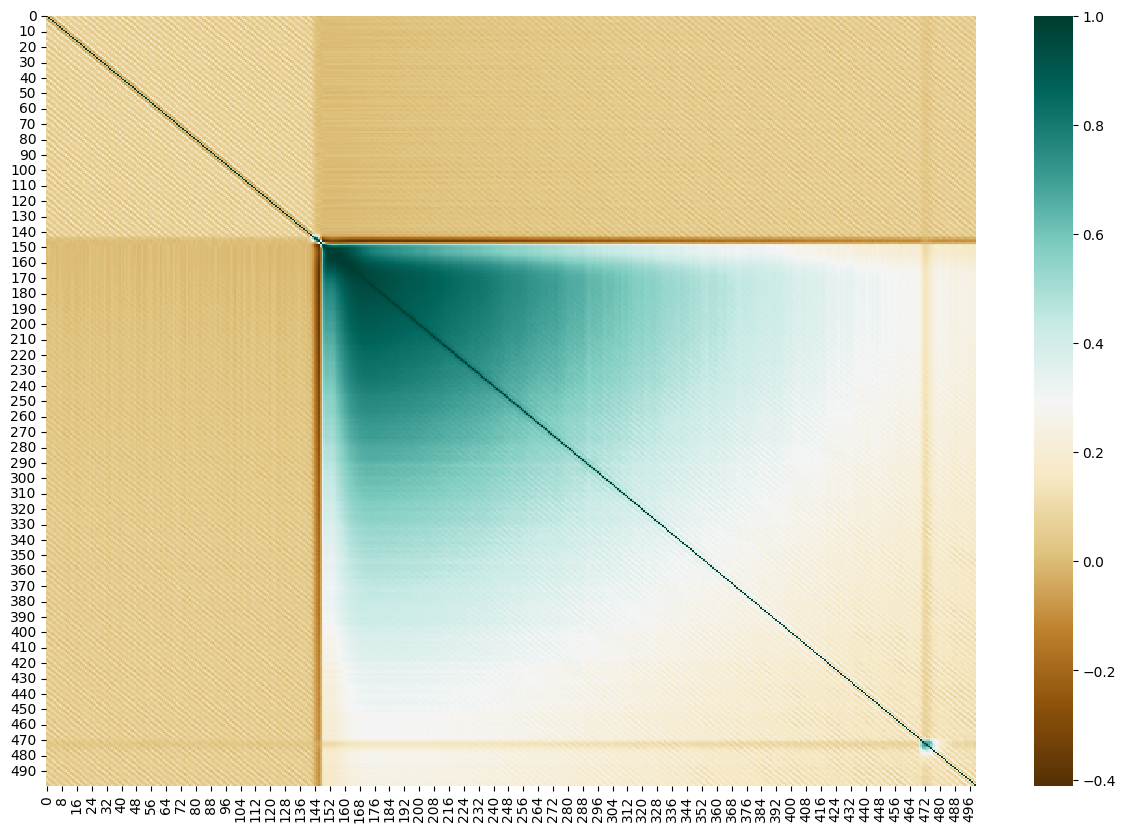

In [8]:
df_corr = df.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG",ax=ax)
plt.show()

In [9]:
def find_correlated_pairs(corr_matrix, threshold=0.7):
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

    pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > threshold:
                pairs.append({
                    'Признак_1': corr_matrix.columns[i],
                    'Признак_2': corr_matrix.columns[j],
                    'Корреляция': corr_value,
                    '|Корреляция|': abs(corr_value)
                })

    return pd.DataFrame(pairs).sort_values('|Корреляция|', ascending=False)

threshold = 0.5
correlated_pairs = find_correlated_pairs(df_corr, threshold)

print(f"Найдено коррелирующих пар: {len(correlated_pairs)}")
print("\nТОП-50 самых сильных корреляций:")
print(correlated_pairs.head(50))

Найдено коррелирующих пар: 14353

ТОП-50 самых сильных корреляций:
      Признак_1  Признак_2  Корреляция  |Корреляция|
675         154        155    0.998881      0.998881
553         153        154    0.998596      0.998596
798         155        156    0.998429      0.998429
924         156        157    0.998035      0.998035
1057        157        158    0.997800      0.997800
431         152        153    0.997797      0.997797
1197        158        159    0.997160      0.997160
554         153        155    0.996733      0.996733
676         154        156    0.996496      0.996496
1344        159        160    0.996279      0.996279
799         155        157    0.995260      0.995260
1497        160        161    0.995209      0.995209
307         151        152    0.995058      0.995058
925         156        158    0.994809      0.994809
1652        161        162    0.994244      0.994244
432         152        154    0.994178      0.994178
1058        157        159    0.

## График сигналов

Text(0, 0.5, 'bit ADC')

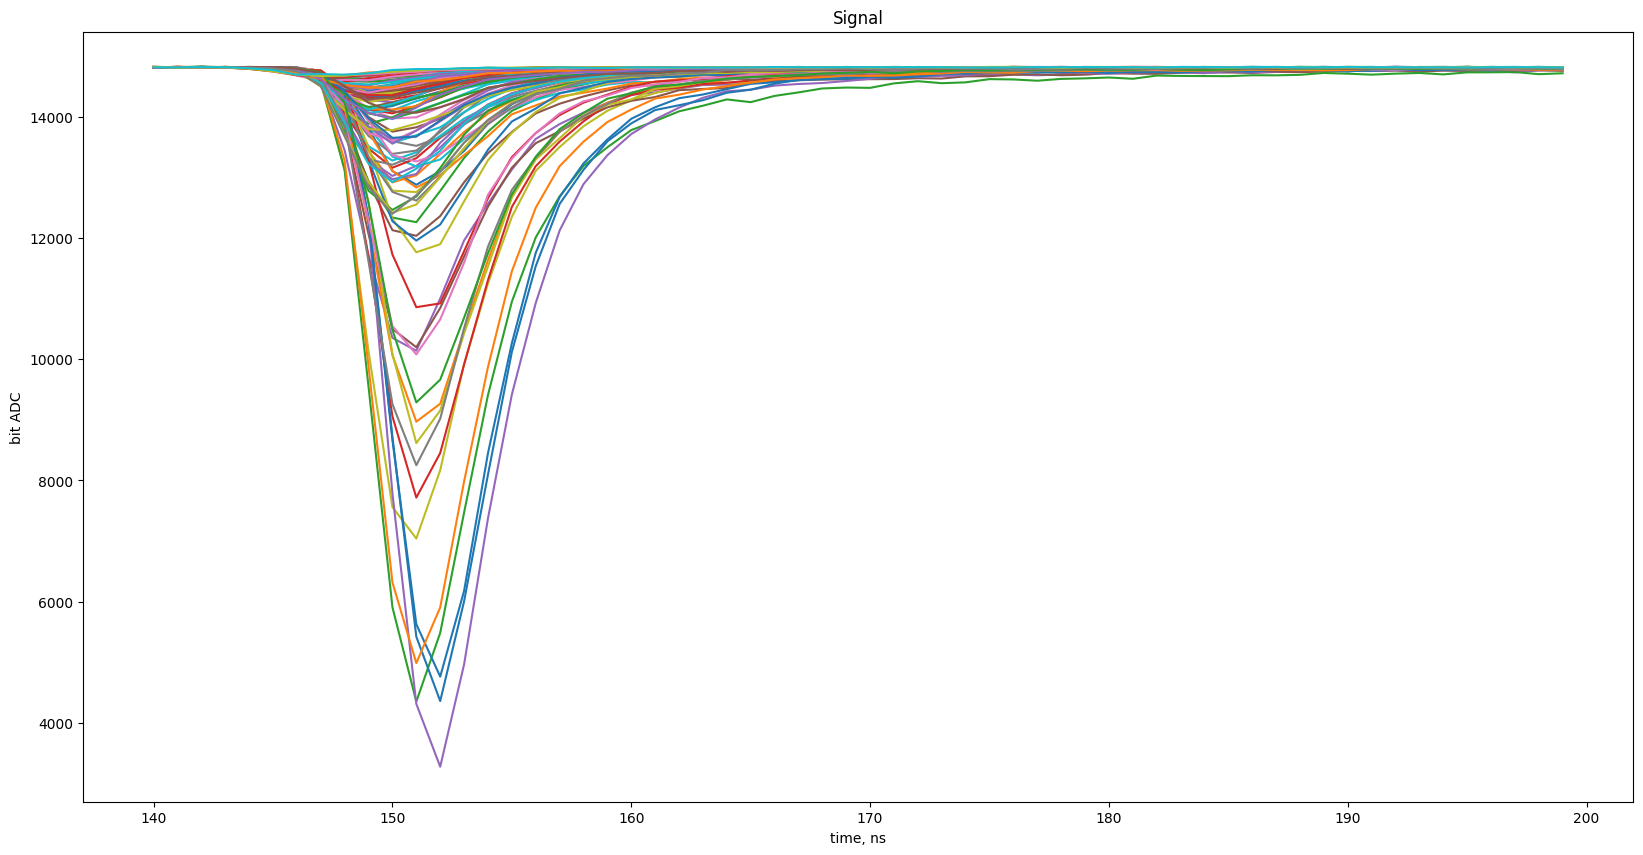

In [10]:
N=range(0,100)
ax = df.T[N][140:200].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")

Text(0, 0.5, 'bit ADC')

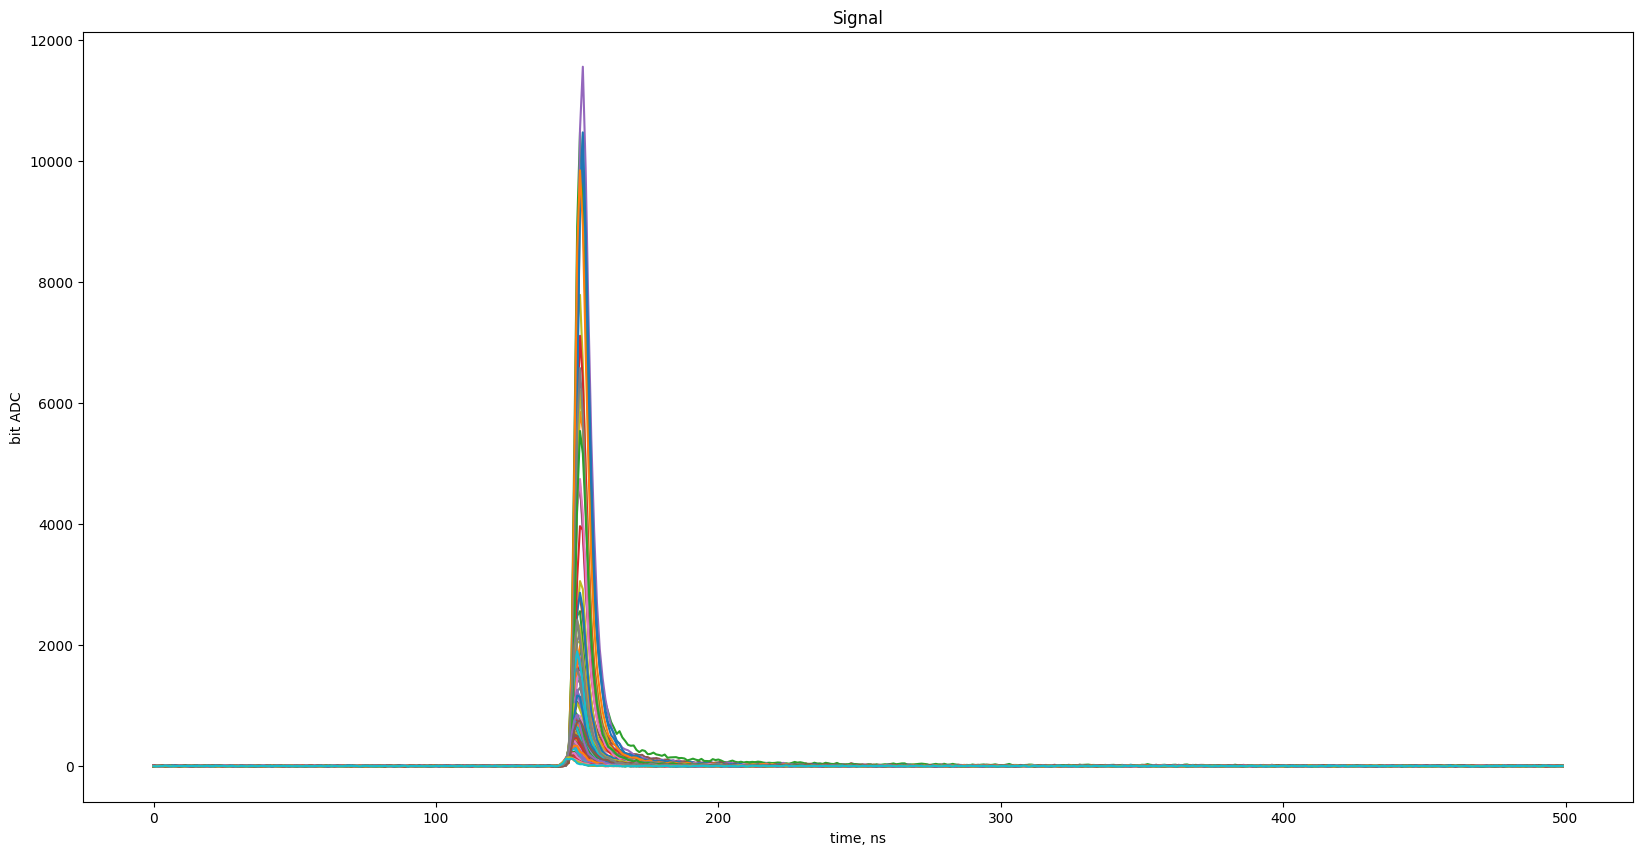

In [11]:
ax = (2**14-df.T[N]-1560)[0:500].plot(title='Signal' ,legend=None,figsize=(20,10))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC")


## Вывод


1) Видна сильная линейная зависимость некотрых признаков на матрице корреляции. Но смысла их обрабатывать практически нет,т.к. нам необходимо отбирать значения по графику сигналов. Я конечно по началу пробовал методом РСА и UMAP, но это не приносило успеха.
2) На графике сигналов мы видим, что информативны для нас признаки с 145 до 200 или 250 включительно.

# Предварительная обработка

## Стандартизация данных

In [12]:
df_std = StandardScaler().fit_transform(df)

scaled_df = pd.DataFrame(df_std, index=df.index, columns=df.columns)
scaled_df

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,-1.059338,0.014656,0.362582,-0.347121,-1.766092,-1.050211,0.364297,-0.337571,-1.041261,-1.054826,...,1.688835,-0.093578,-2.176853,-2.152072,-1.597798,-1.026272,-0.697408,-0.085559,-0.703227,-1.012801
1,-1.059338,-0.338270,-1.045524,1.055401,0.351541,-0.345045,-1.048542,-0.337571,0.012764,-0.699535,...,1.688835,-1.575721,0.517245,-0.051532,0.529713,-1.026272,-0.697408,-1.008317,-0.088461,-0.704372
2,-1.059338,-1.044122,-0.341471,0.704770,-1.060215,0.360122,0.364297,-1.398592,0.012764,0.366338,...,-0.693588,-0.390007,-0.680132,-0.651686,-1.293868,-0.407494,0.220476,-0.700731,-0.703227,-0.395944
3,1.791874,-0.338270,-1.749578,0.354140,0.351541,-0.345045,-1.048542,-0.337571,0.364106,-1.054826,...,0.497623,1.092135,-0.081443,-0.351609,-0.686008,1.758230,-0.697408,-0.085559,0.218921,-0.087515
4,0.009867,-2.808751,0.010555,-0.697752,1.410358,-1.050211,0.011087,0.369776,-2.446629,-0.699535,...,-0.693588,-0.686435,0.217901,1.748931,0.529713,-0.716883,0.526437,0.529613,-0.088461,0.837772
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,1.079071,1.426359,0.714608,-1.749643,0.704480,1.417871,1.423925,0.016103,0.012764,0.011047,...,1.093229,1.684992,0.816589,-0.951763,1.137573,1.758230,-0.085485,0.529613,0.526304,1.454630
23475,0.366268,0.014656,-1.397551,1.756662,-1.413154,0.360122,0.364297,0.016103,0.364106,-0.699535,...,1.688835,1.092135,0.517245,-2.452149,-2.509588,-1.335661,-1.921252,-0.085559,-1.010610,-1.629659
23476,-0.346535,-0.338270,0.362582,-1.048382,-0.001398,1.770454,0.011087,0.369776,-1.041261,0.366338,...,1.093229,-1.575721,-2.176853,-1.551918,-1.293868,-1.645050,-1.921252,-1.008317,-1.625376,-0.704372
23477,0.366268,0.014656,0.362582,-0.347121,-0.707276,0.360122,-1.048542,-0.337571,1.769474,1.432210,...,0.199821,0.499278,1.415278,-0.051532,0.833643,0.520673,-0.085485,-0.700731,-1.010610,0.529343


## Вывод

1) Данные стандартизированы для дальнейших алгоритмов понижения размерности (которые как показала практика в целом бесполезны и дают плохой результат на kaggle)

# Понижение размерности

## Сколько компонент оставить

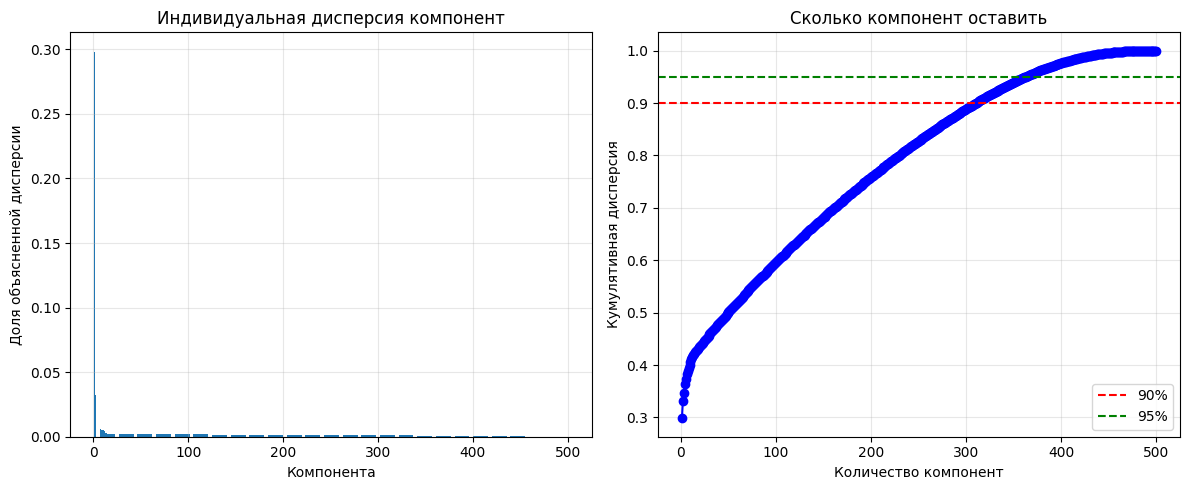

Исходных признаков: 500
Для 60% дисперсии нужно: 102 компонент
Для 80% дисперсии нужно: 230 компонент
Для 90% дисперсии нужно: 311 компонент
Для 95% дисперсии нужно: 363 компонент
Для 99% дисперсии нужно: 430 компонент


In [13]:
pca = PCA()
pca.fit(scaled_df)

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Компонента')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Индивидуальная дисперсия компонент')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum)+1), cumsum, 'bo-')
plt.axhline(y=0.9, color='r', linestyle='--', label='90%')
plt.axhline(y=0.95, color='g', linestyle='--', label='95%')
plt.xlabel('Количество компонент')
plt.ylabel('Кумулятивная дисперсия')
plt.title('Сколько компонент оставить')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_60 = np.argmax(cumsum >= 0.60) + 1
n_80 = np.argmax(cumsum >= 0.80) + 1
n_90 = np.argmax(cumsum >= 0.90) + 1
n_95 = np.argmax(cumsum >= 0.95) + 1
n_99 = np.argmax(cumsum >= 0.99) + 1

print(f"Исходных признаков: {scaled_df.shape[1]}")
print(f"Для 60% дисперсии нужно: {n_60} компонент")
print(f"Для 80% дисперсии нужно: {n_80} компонент")
print(f"Для 90% дисперсии нужно: {n_90} компонент")
print(f"Для 95% дисперсии нужно: {n_95} компонент")
print(f"Для 99% дисперсии нужно: {n_99} компонент")

## Применение РСА

In [14]:
pca = PCA(n_components=0.90)

principalComponents = pca.fit_transform(scaled_df)

principalDf = pd.DataFrame(data = principalComponents)

In [15]:
principalDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Columns: 311 entries, 0 to 310
dtypes: float64(311)
memory usage: 55.7 MB


## Применение UMAP

In [16]:
umap_reducer = umap.UMAP(
    n_components=100,
    n_neighbors=15,
    min_dist=0.3,
    metric='euclidean',
    random_state=42
)

X_umap = umap_reducer.fit_transform(scaled_df)
print(f"UMAP размерность: {X_umap.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP размерность: (23479, 100)


## Проверка матрицы корреляции

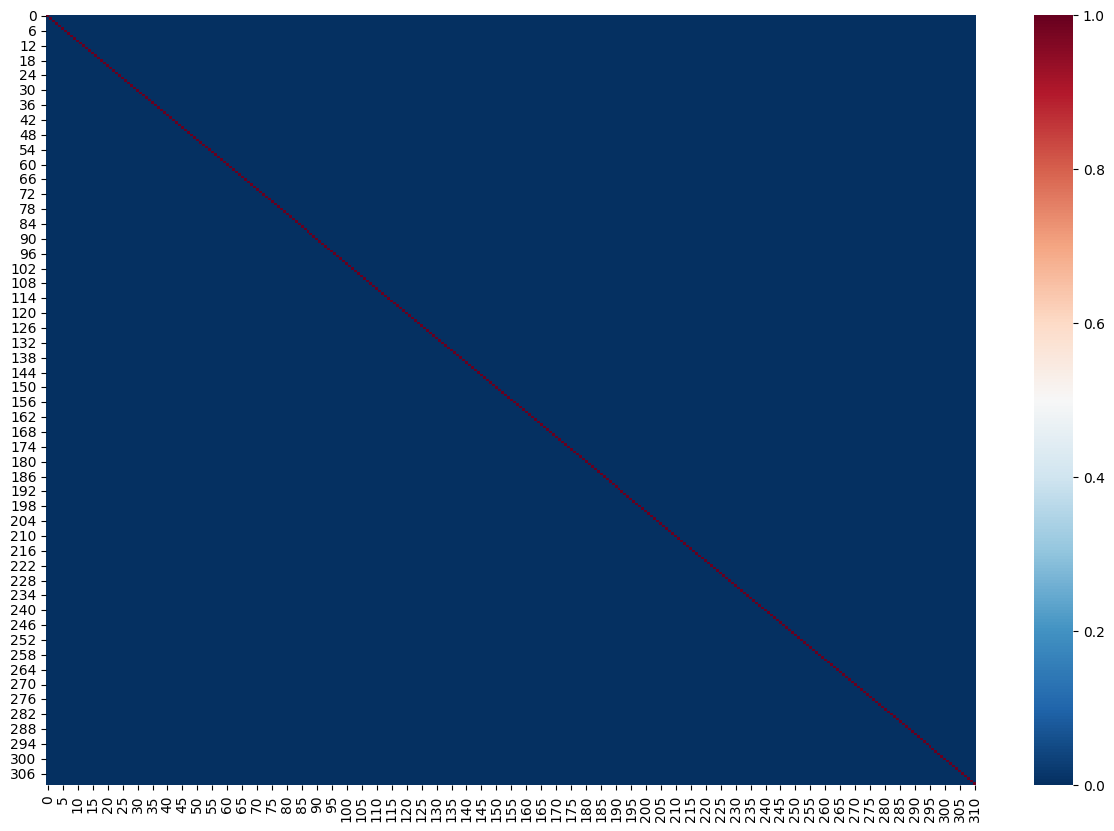

In [17]:
principalDf_corr = principalDf.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(principalDf_corr, mask=np.zeros_like(principalDf_corr, dtype=np.bool), cmap = "RdBu_r",ax=ax)
plt.show()

##Вывод

1) Благодаря применению РСА убрана линейная зависимость из признаков.

2) Также при помощь UMAP отобрали другие признаки, которые для тестирования будем использовать в DBscan.

# Кластеризация K-means

## Метод силуэта

Использую признаки, которые уменьшил с помощью РСА

k = 2: коэффициент силуэта = 0.3013
k = 3: коэффициент силуэта = 0.1565


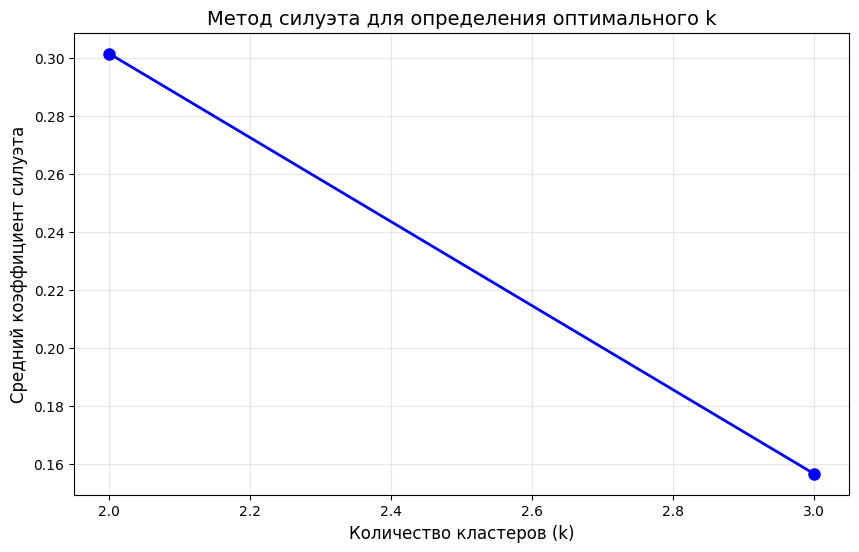

In [18]:
n_init = 12
random_state = 42

k_range = range(2, 4)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k,
                    random_state=random_state,
                    n_init=n_init)
    labels = kmeans.fit_predict(principalComponents)

    score = silhouette_score(principalComponents, labels)
    silhouette_scores.append(score)

    print(f"k = {k}: коэффициент силуэта = {score:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Количество кластеров (k)', fontsize=12)
plt.ylabel('Средний коэффициент силуэта', fontsize=12)
plt.title('Метод силуэта для определения оптимального k', fontsize=14)
plt.grid(True, alpha=0.3)

## Обучение алгоритма

In [19]:
n_init = 12
random_state = 42
n_clusters = 3

clusterer = KMeans(n_clusters=n_clusters, random_state = random_state)

cluster_labels = clusterer.fit_predict(principalComponents)

## Подготовка ответа

In [20]:
predictions = pd.DataFrame(cluster_labels, columns=['cluster'])
predictions = predictions.reset_index()

predictions

,index,cluster
0,0,0
1,1,2
2,2,0
3,3,2
4,4,2
...,...,...
23474,23474,2
23475,23475,1
23476,23476,1
23477,23477,0


In [21]:
predictions['cluster'].unique()

array([0, 2, 1], dtype=int32)

In [22]:
mapping = {
    0:0,
    2:1,
    1:2
}

predictions['new'] = predictions['cluster'].map(mapping).fillna(-1).astype(int)

print(predictions['new'].value_counts().sort_index())



new
0     5878
1    15927
2     1674
Name: count, dtype: int64


In [23]:
predictions = predictions.drop(columns=['cluster'])

predictions = predictions.rename(columns={"new": "cluster"})
predictions.head()


,index,cluster
0,0,0
1,1,1
2,2,0
3,3,1
4,4,1


In [24]:
print(predictions['cluster'].unique())

predictions.to_csv("k-means.csv", index=False)

files.download("k-means.csv")

[0 1 2]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Вывод

1) По методу силуэта лучше всего выбрать 2 кластера для кластеризации

2) В описании задачи сказано про 3 кластера, но скорее всего последний класс очень мал и его можно опустить. Протестировал решение на kaggle с двумя и тремя кластерами

Результат:

* 2 кластера - 0.306
* 3 кластера - 0.510 (работает лучше)

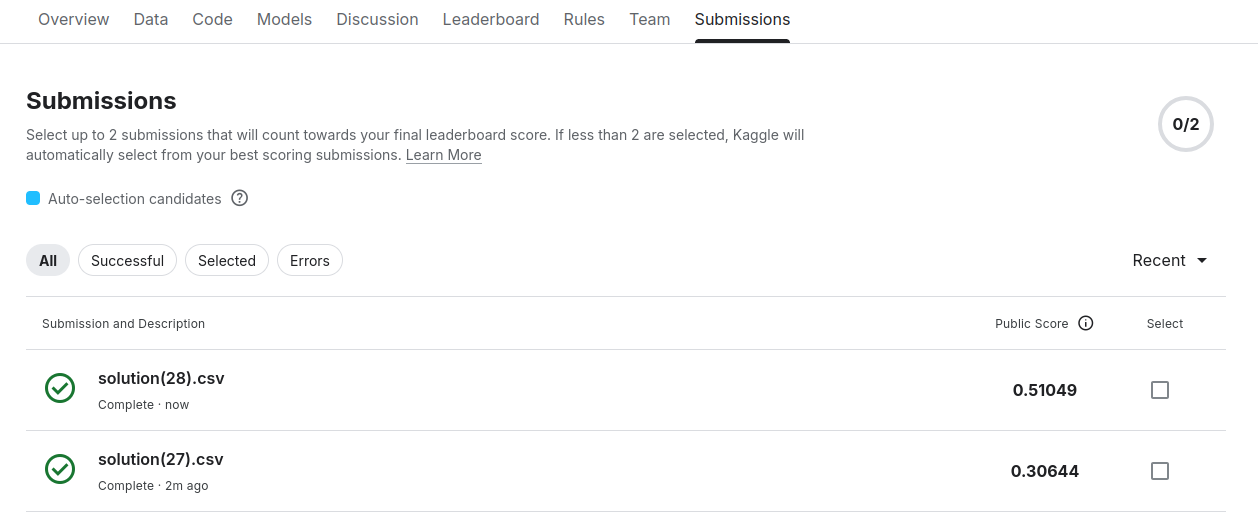

# Кластеризация DBSCAN

## Метод локтя

Использую признаки, которые уменьшил с помощью UMAP

Вычисляем расстояния до 99-го ближайшего соседа...
Всего точек: 23479

 Результаты:
   Оптимальный eps: 0.355
   Позиция локтя: точка 1182 из 23479
   Процент точек до локтя: 5.0%


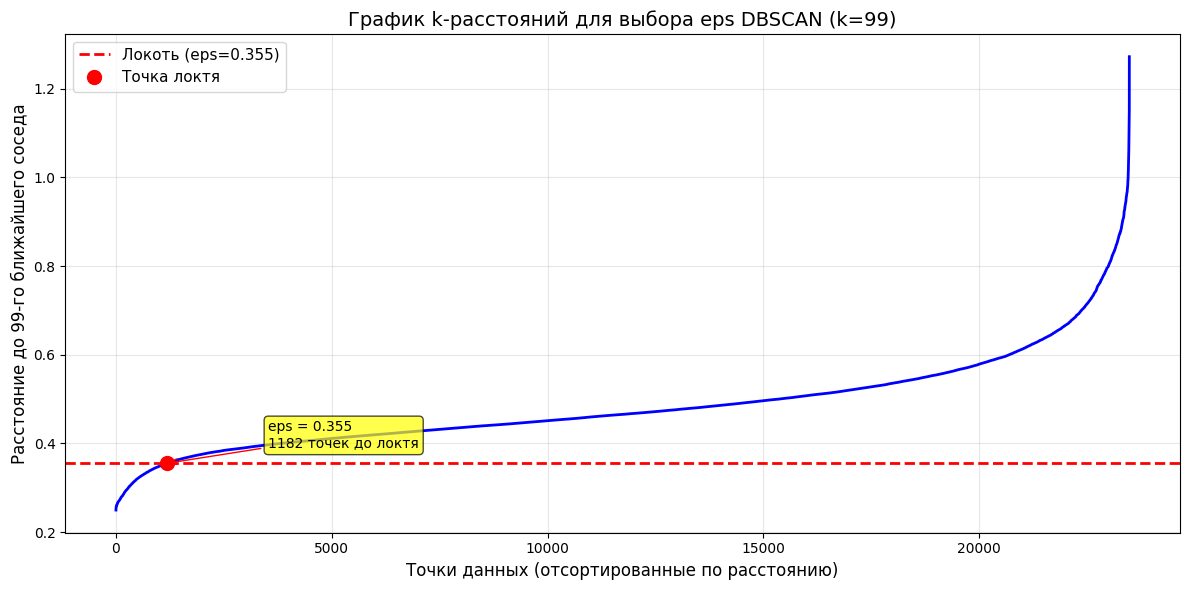

In [25]:
min_samples = 100
k = min_samples - 1

print(f"Вычисляем расстояния до {k}-го ближайшего соседа...")

nbrs = NearestNeighbors(n_neighbors=k, n_jobs=-1)
nbrs.fit(X_umap)
distances, indices = nbrs.kneighbors(X_umap)

k_distances = distances[:, -1]

sorted_distances = np.sort(k_distances)

print(f"Всего точек: {len(sorted_distances)}")

def find_knee(sorted_distances):
    n = len(sorted_distances)
    diffs = np.diff(sorted_distances)

    start_idx = int(n * 0.05)
    end_idx = int(n * 0.8)

    knee_idx = start_idx + np.argmax(diffs[start_idx:end_idx])
    eps_value = sorted_distances[knee_idx]

    return eps_value, knee_idx

eps_optimal, knee_idx = find_knee(sorted_distances)

print(f"\n Результаты:")
print(f"   Оптимальный eps: {eps_optimal:.3f}")
print(f"   Позиция локтя: точка {knee_idx} из {len(sorted_distances)}")
print(f"   Процент точек до локтя: {knee_idx/len(sorted_distances)*100:.1f}%")

plt.figure(figsize=(12, 6))
plt.plot(sorted_distances, 'b-', linewidth=2)
plt.axhline(y=eps_optimal, color='r', linestyle='--', linewidth=2,
            label=f'Локоть (eps={eps_optimal:.3f})')
plt.plot(knee_idx, eps_optimal, 'ro', markersize=10, label='Точка локтя')
plt.xlabel("Точки данных (отсортированные по расстоянию)", fontsize=12)
plt.ylabel(f"Расстояние до {k}-го ближайшего соседа", fontsize=12)
plt.title(f"График k-расстояний для выбора eps DBSCAN (k={k})", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.annotate(f'eps = {eps_optimal:.3f}\n{knee_idx} точек до локтя',
             xy=(knee_idx, eps_optimal),
             xytext=(knee_idx + len(sorted_distances)*0.1, eps_optimal + eps_optimal*0.1),
             arrowprops=dict(arrowstyle='->', color='red'),
             fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

## Обучение алгоритма




In [26]:
eps = 0.355
min_samples = 100
dbscan = DBSCAN(
    eps=eps,
    min_samples=min_samples,
    metric='euclidean',
    algorithm='auto',
    n_jobs=-1
)
cluster_labels = dbscan.fit_predict(principalComponents)

## Подготовка ответа

In [27]:
predictions = pd.DataFrame(cluster_labels, columns=['cluster'])
predictions = predictions.reset_index()

predictions

,index,cluster
0,0,-1
1,1,-1
2,2,-1
3,3,-1
4,4,-1
...,...,...
23474,23474,-1
23475,23475,-1
23476,23476,-1
23477,23477,-1


In [28]:
predictions['cluster'].unique()

array([-1])

## Вывод


1) Понижение размерности UMAP с совокупным методом DBSCAN работает плохо. Приходиться играть угадайку как правильно выделить кластеры и подобрать eps.

2) Метод локтя не помог в итоге DBSCAN закидывает все точки в шум (возможно стоит уменьшить размерность до 50 или даже 20 признаков,тогда DBSCAN будет работать лучше)

# Эвристический подход

Основная идея

Подход базируется на предположении, что:

* Данные состоят из двух основных классов (например, сигнал/шум, норма/аномалия)

* Признак psd имеет бимодальное распределение (два пика на гистограмме)

* Оптимальный порог разделения находится в минимуме между этими пиками

Распределение: [10800 12675     4]
Шум: 0.0%


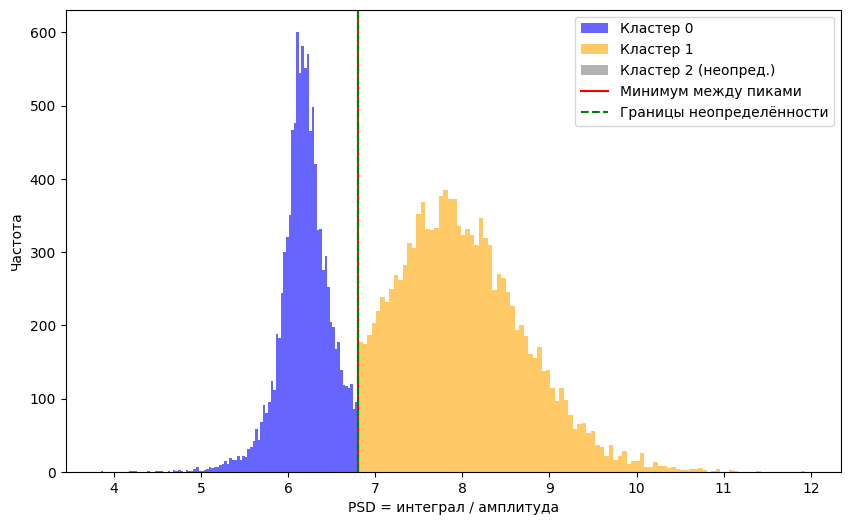

In [29]:
left, right = 145, 200
window_data = df.iloc[:, left:right].values
transformed_signal = (16384 - window_data - 1560)
amplitude_max = transformed_signal.max(axis=1)
area_under_curve = transformed_signal.sum(axis=1)
shape_feature = area_under_curve / amplitude_max

histogram, bin_edges = np.histogram(shape_feature, bins=300, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothed_histogram = gaussian_filter1d(histogram, sigma=1.5)

detected_peaks, _ = find_peaks(smoothed_histogram, height=0.01, distance=30)

if len(detected_peaks) < 2:
    mixture_model = GaussianMixture(n_components=2, random_state=42)
    mixture_model.fit(shape_feature.reshape(-1, 1))
    cluster_centers = mixture_model.means_.ravel()
    splitting_threshold = (cluster_centers[0] + cluster_centers[1]) / 2
    center_distance = abs(cluster_centers[1] - cluster_centers[0])
else:
    peak_magnitudes = smoothed_histogram[detected_peaks]
    sorted_peak_indices = np.argsort(peak_magnitudes)[-2:]
    left_peak_pos = min(detected_peaks[sorted_peak_indices])
    right_peak_pos = max(detected_peaks[sorted_peak_indices])
    valley_index = np.argmin(smoothed_histogram[left_peak_pos:right_peak_pos + 1]) + left_peak_pos
    splitting_threshold = bin_centers[valley_index]
    center_distance = bin_centers[right_peak_pos] - bin_centers[left_peak_pos]

uncertainty_margin = 0.0005 * center_distance

lower_bound = splitting_threshold - uncertainty_margin
upper_bound = splitting_threshold + uncertainty_margin

cluster_labels = np.full(len(shape_feature), 2, dtype=int)
cluster_labels[shape_feature < lower_bound] = 0
cluster_labels[shape_feature > upper_bound] = 1

print("Распределение:", np.bincount(cluster_labels))
print(f"Шум: {100 * (cluster_labels == 2).mean():.1f}%")

plt.figure(figsize=(10, 6))
plt.hist(shape_feature[cluster_labels == 0], bins=100, alpha=0.6, label='Кластер 0', color='blue')
plt.hist(shape_feature[cluster_labels == 1], bins=100, alpha=0.6, label='Кластер 1', color='orange')
plt.hist(shape_feature[cluster_labels == 2], bins=100, alpha=0.6, label='Кластер 2 (неопред.)', color='gray')
plt.axvline(splitting_threshold, color='r', linestyle='-', label='Минимум между пиками')
plt.axvline(lower_bound, color='g', linestyle='--', label='Границы неопределённости')
plt.axvline(upper_bound, color='g', linestyle='--')
plt.xlabel('PSD = интеграл / амплитуда')
plt.ylabel('Частота')
plt.legend()
plt.show()

## Подготовка ответа

In [30]:
submission_with_id = pd.DataFrame({
    'index': df.index,
    'cluster': cluster_labels
})

submission_with_id['cluster'].unique()


array([1, 0, 2])

In [31]:
mapping = {
    1:0,
    0:1,
    2:2
}
submission_with_id['new'] = submission_with_id['cluster'].map(mapping).fillna(-1).astype(int)

print(submission_with_id['new'].value_counts().sort_index())

new
0    12675
1    10800
2        4
Name: count, dtype: int64


In [32]:
submission_with_id = submission_with_id.drop(columns=['cluster'])

submission_with_id = submission_with_id.rename(columns={"new": "cluster"})
submission_with_id.head()


,index,cluster
0,0,0
1,1,1
2,2,1
3,3,0
4,4,1


In [33]:
submission_with_id['cluster'].unique()

array([0, 1, 2])

In [34]:
submission_with_id.to_csv("evristic_method.csv", index=False)

files.download("evristic_method.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Вывод

1) Подход основан на анализе гистограммы и поиске естественного разрыва в распределении данных.

2) Даёт хорошую метрику на kaggle (0.82354)

3) Не является классическим ML алгоритмом - больше статистический метод

4) Брали признаки из 145 по 200 столбец (исходя из графиков сигналов)

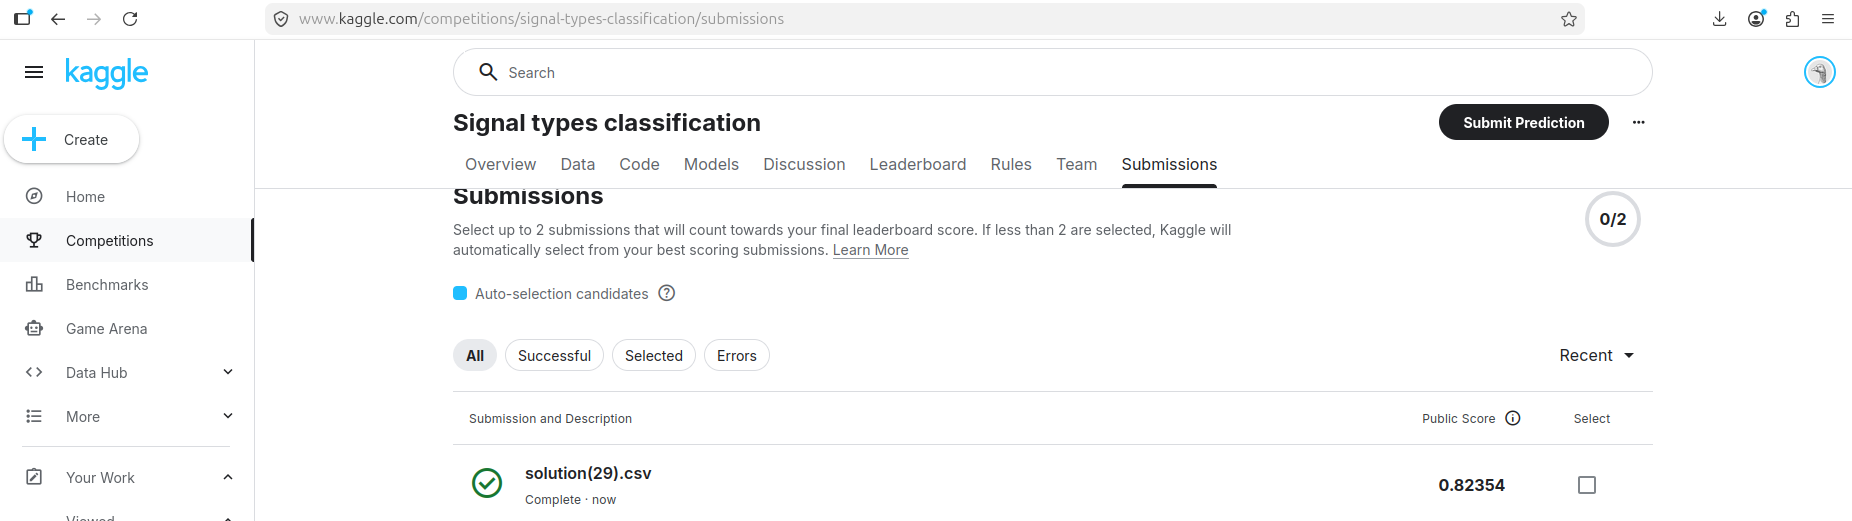

# Решение с максимальным score

**Решение нашёл в интернете**

In [35]:
df = pd.read_csv('/root/.cache/kagglehub/competitions/signal-types-classification/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
print(f"Исходно: {df.shape}")


data = df.iloc[:, 4:504]
data.columns = range(500)
print(f"Волновые каналы: {data.shape}")

data = 2**14 - data - 1560
data = data.clip(lower=1)
data["amp"] = data.max(axis=1)
print(f"Амплитуды: {data['amp'].min():.0f} – {data['amp'].max():.0f}")

data_test = pd.DataFrame(0, index=data.index, columns=["cluster"])
data_test.loc[data["amp"] > 14000, "cluster"] = 1

def process(start, end, step):
    for threshold in range(start, end, -step):
        amplitude_mask = (data["amp"] > threshold) & (data["amp"] <= threshold + step)
        selected_data = data.loc[amplitude_mask, range(500)]

        if len(selected_data) < 10:
            print(f"Диапазон ({threshold}-{threshold+step}]: пропущено ({len(selected_data)})")
            continue

        truncated_data = selected_data.loc[:, 145:250]

        feature_list = []
        for idx in truncated_data.index:
            waveform = truncated_data.loc[idx].values
            peak_position = np.argmax(waveform)
            tail_start = min(peak_position + 8, len(waveform) - 52)
            tail_end = tail_start + 52
            tail_region = waveform[tail_start:tail_end]
            cumulative_tail = np.cumsum(tail_region)
            tail_area = cumulative_tail[min(29, len(cumulative_tail) - 1)]
            feature_list.append(np.log(max(tail_area, 1)))

        feature_matrix = np.array(feature_list).reshape(-1, 1)
        cluster_model = KMeans(n_clusters=2, n_init=10, random_state=42)
        cluster_assignments = cluster_model.fit_predict(feature_matrix)

        cluster_zero_mean = feature_matrix[cluster_assignments == 0].mean()
        cluster_one_mean = feature_matrix[cluster_assignments == 1].mean()
        label_mapping = {0: 0, 1: 1} if cluster_zero_mean > cluster_one_mean else {0: 1, 1: 0}

        zero_cluster_mask = cluster_assignments == 0
        data_test.loc[truncated_data.index[zero_cluster_mask], "cluster"] = label_mapping[0]
        data_test.loc[truncated_data.index[~zero_cluster_mask], "cluster"] = label_mapping[1]

        print(f"Диапазон ({threshold}-{threshold+step}]: {len(selected_data)} → {np.bincount(cluster_assignments)}")

amplitude_ranges = [(13000, 1000, 1000), (2500, 500, 500), (800, 200, 200), (380, 200, 20), (210, 99, 10)]
for start_val, end_val, step_val in amplitude_ranges:
    process(start_val, end_val, step_val)


Исходно: (23479, 505)
Волновые каналы: (23479, 500)
Амплитуды: 105 – 14824
Диапазон (13000-14000]: пропущено (7)
Диапазон (12000-13000]: 64 → [49 15]
Диапазон (11000-12000]: 162 → [148  14]
Диапазон (10000-11000]: 204 → [178  26]
Диапазон (9000-10000]: 215 → [169  46]
Диапазон (8000-9000]: 260 → [185  75]
Диапазон (7000-8000]: 323 → [224  99]
Диапазон (6000-7000]: 491 → [333 158]
Диапазон (5000-6000]: 710 → [463 247]
Диапазон (4000-5000]: 916 → [407 509]
Диапазон (3000-4000]: 1311 → [615 696]
Диапазон (2000-3000]: 1948 → [ 897 1051]
Диапазон (2500-3000]: 823 → [380 443]
Диапазон (2000-2500]: 1125 → [517 608]
Диапазон (1500-2000]: 1536 → [881 655]
Диапазон (1000-1500]: 2171 → [1293  878]
Диапазон (800-1000]: 1520 → [773 747]
Диапазон (600-800]: 1879 → [951 928]
Диапазон (400-600]: 2368 → [1098 1270]
Диапазон (380-400]: 303 → [171 132]
Диапазон (360-380]: 344 → [165 179]
Диапазон (340-360]: 301 → [145 156]
Диапазон (320-340]: 353 → [179 174]
Диапазон (300-320]: 378 → [201 177]
Диапазон (

## Подготовка ответа

In [36]:
predictions = pd.DataFrame({
    'index': data.index,
    'cluster': data_test['cluster'].astype(int)
})

In [37]:
predictions['cluster'].unique()

array([0, 1])

In [38]:
print(predictions['cluster'].unique())

predictions.to_csv("max_score.csv", index=False)

files.download("max_score.csv")

[0 1]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Вывод

1) Лучший результат на kaggle даёт данный алгоритм
2) Диапазон значений подбирася вручную

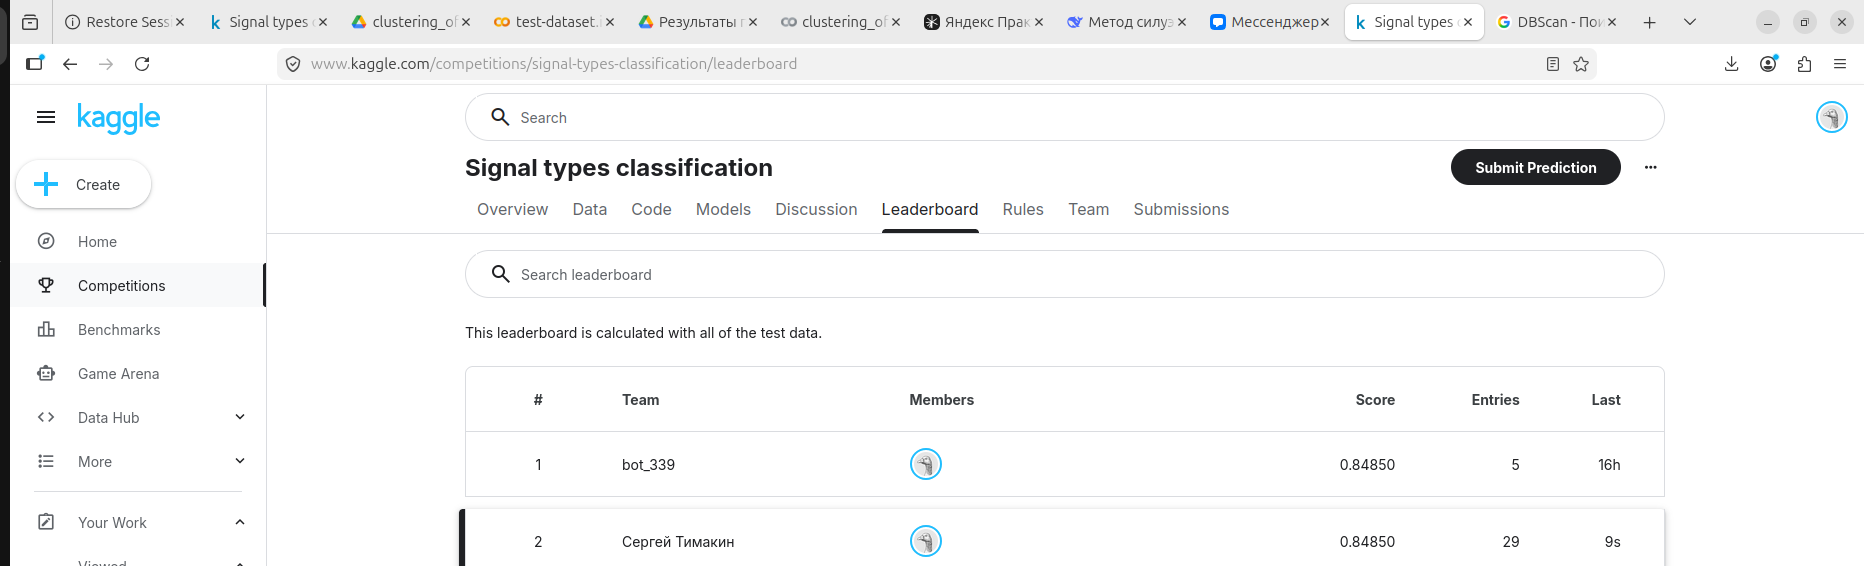

# Итоговый вывод

1) Произведен предварительный анализ и предобработка данных. Отобраны необходимые признаки для обучения модели (при помощи графиков сигналов) и построена матрица корреляции для поиска линейных зависимостей

2) Понижена размерность признаков при помощи РСА и UMAP для тестирования различных решений

3) Произведена кластеризация K-means на основе признаков полученных из РСА (результат около 0.5 на каггле)

4) Произведена кластеризация при помощи DBSCAN - результат оказался плохим, все метрики попадают в шум

5) Эвристический подход дал хороший результат по разделению кластеров

